In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, accuracy_score, precision_score, confusion_matrix, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("✅ All libraries imported!")

✅ All libraries imported!


### Load & Explore Data

In [3]:
df = pd.read_csv("../data/raw/customer_churn.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Data types and nulls
print("Data Types:")
print(df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())


Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values: 0


In [5]:
# Target class distribution
churn_counts = df['Churn'].value_counts()
print("Churn Distribution:")
print(churn_counts)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


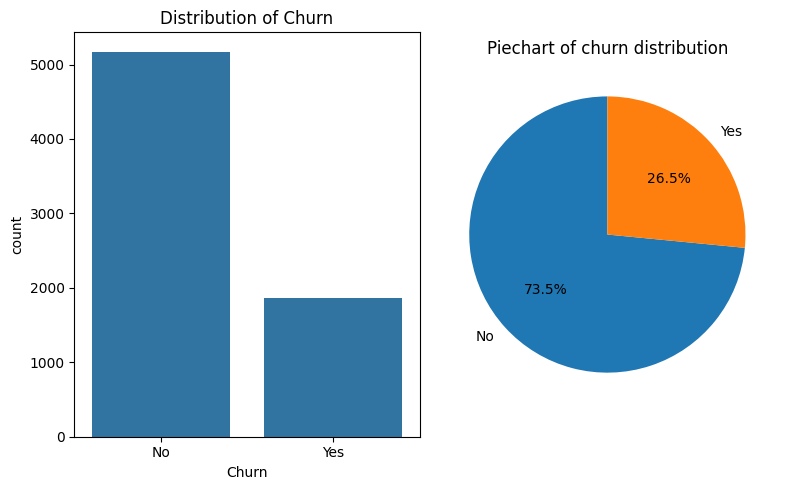

In [6]:
fig, axes = plt.subplots(1,2, figsize= (8,5))
axes = axes.flatten()

sns.countplot(x="Churn", data=df, ax=axes[0])
axes[0].set_title("Distribution of Churn")

axes[1].pie(churn_counts, labels= churn_counts.index, autopct= "%1.1f%%", startangle=90)
axes[1].set_title("Piechart of churn distribution")

plt.tight_layout()
plt.show()

In [7]:
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
cat_cols = df.select_dtypes(exclude=["float64", "int64"]).columns

In [8]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

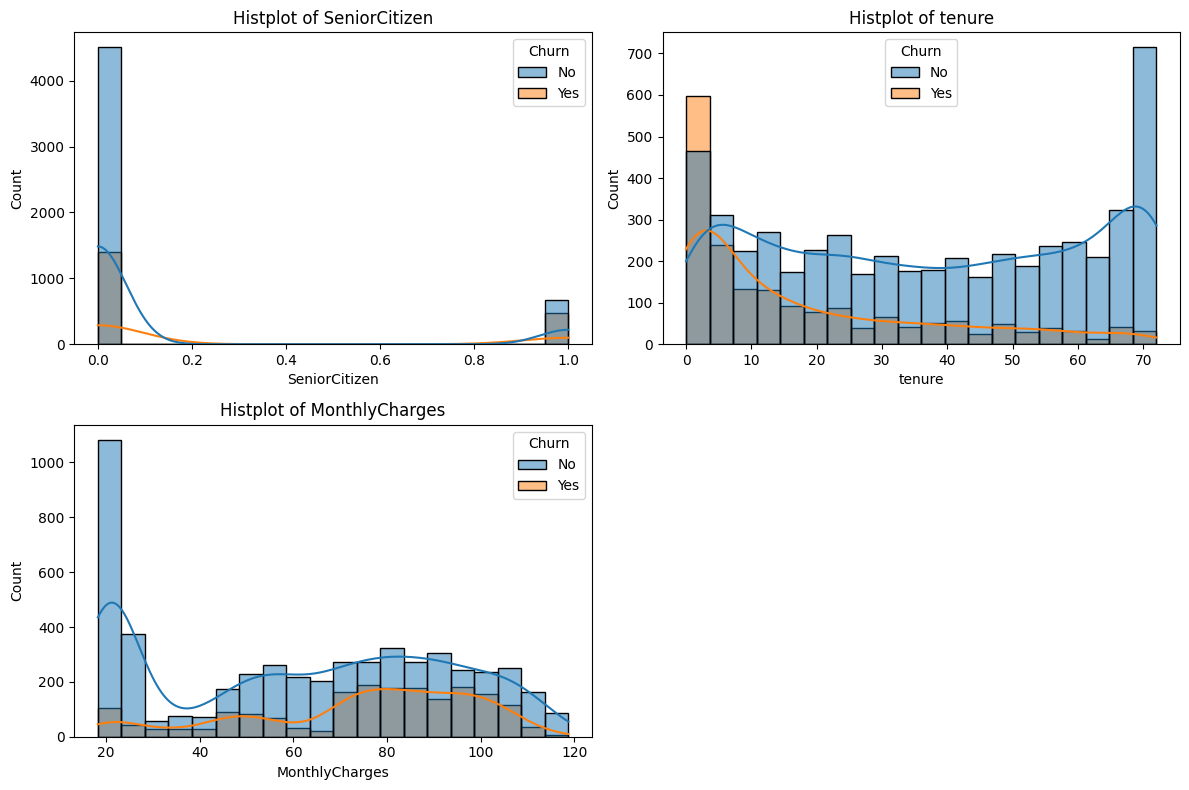

In [9]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes= axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(x=col, kde=True, bins=20, ax=axes[i], data=df, hue="Churn")
    axes[i].set_title(f"Histplot of {col}")
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()    

In [10]:
# from scipy.stats import skew

# print(f"Skewness before log transformation: \n{df[num_cols].skew()}")
# print(f"\nSkewness after log transformation: \n{np.log1p(df[num_cols]).skew()}")

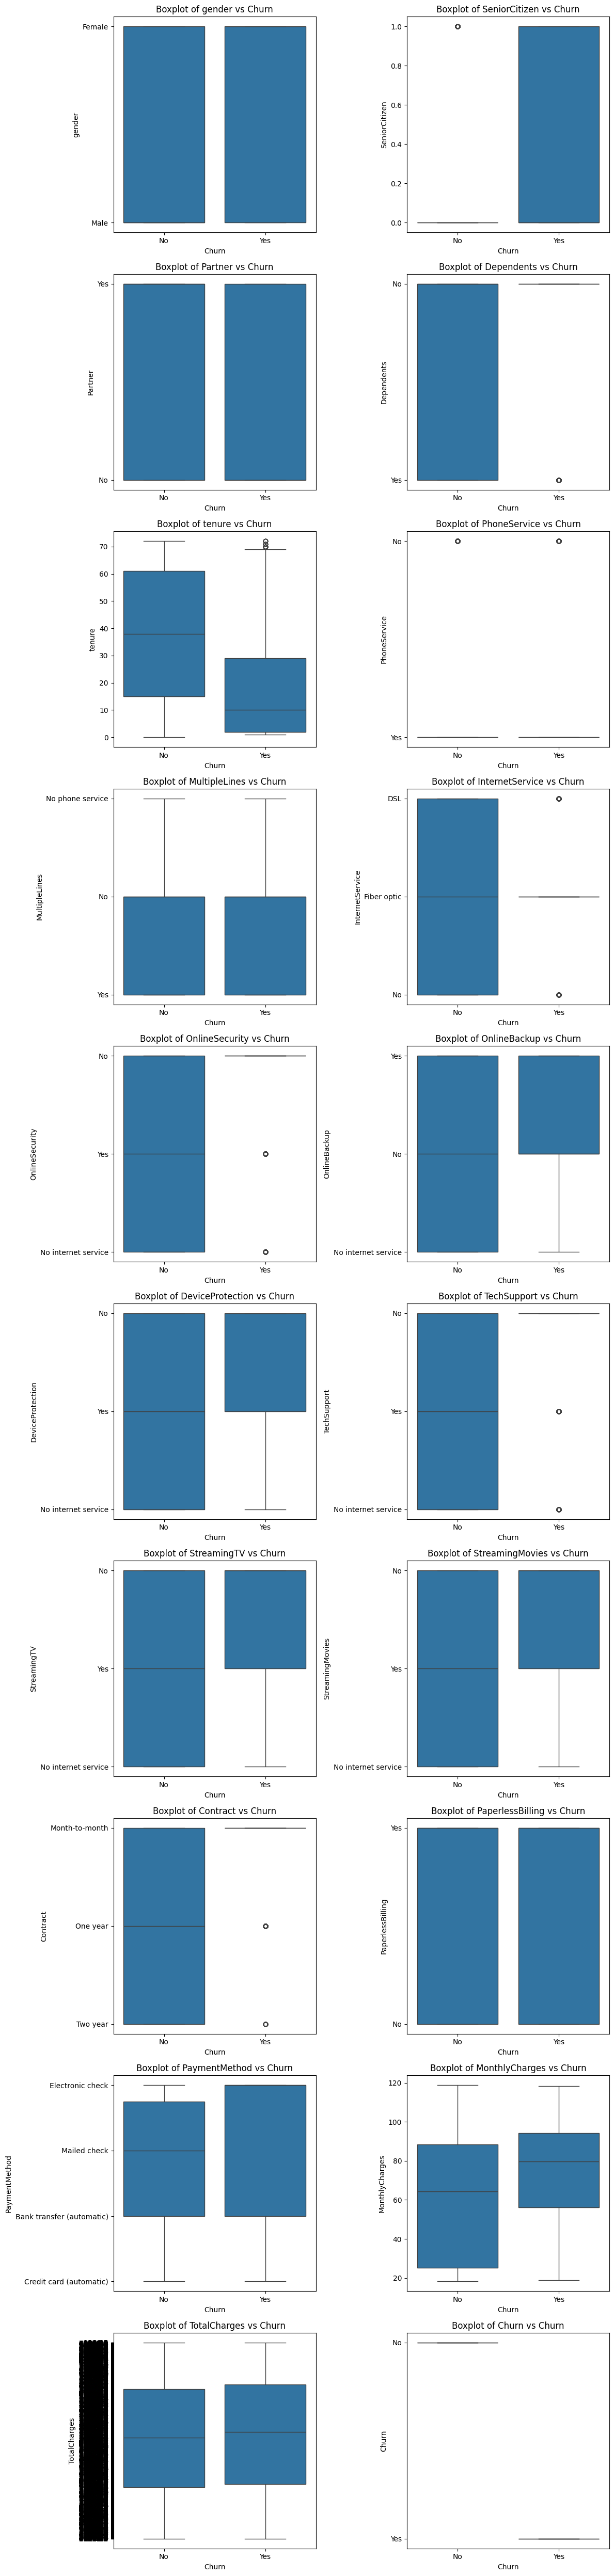

In [11]:
cols = df.columns.drop("customerID")

n = len(cols)
rows = (n + 1) // 2

fig, axes = plt.subplots(rows, 2, figsize=(12, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x="Churn", y=col, data=df, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} vs Churn")

# remove extra empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

 ### Preprocessing

**Strategy:**
- **Drop**: `customerID` (not useful)
- **LabelEncoder**: binary columns (Yes/No, Male/Female)  
- **OneHotEncoder**: multi-category columns
- **StandardScaler**: numeric columns

In [12]:
df_proc = df.copy()

In [13]:
df_proc = df_proc.drop(columns=["customerID"])

In [14]:
df_proc.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df_proc["TotalCharges"] = pd.to_numeric(df_proc["TotalCharges"], errors="coerce")

In [16]:
df_proc[pd.to_numeric(df_proc["TotalCharges"], errors="coerce").isna()]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [17]:
df_proc["TotalCharges"] = df_proc["TotalCharges"].fillna(df_proc["TotalCharges"].median())

In [18]:
df_proc.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


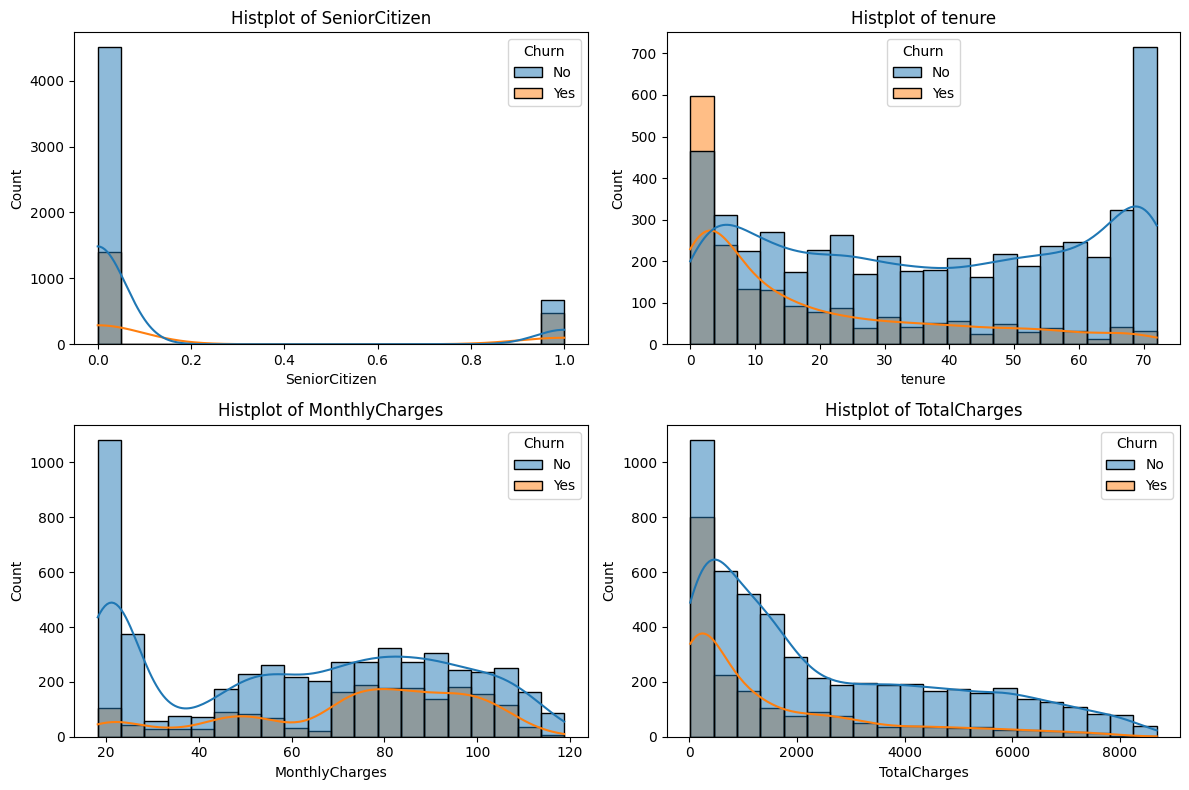

In [19]:
num_cols= ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2,2, figsize=(12,8))
axes= axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(x=col, kde=True, bins=20, ax=axes[i], data=df_proc, hue="Churn")
    axes[i].set_title(f"Histplot of {col}")
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()    

In [20]:
df_proc["TotalCharges"] = np.log1p(df_proc["TotalCharges"])

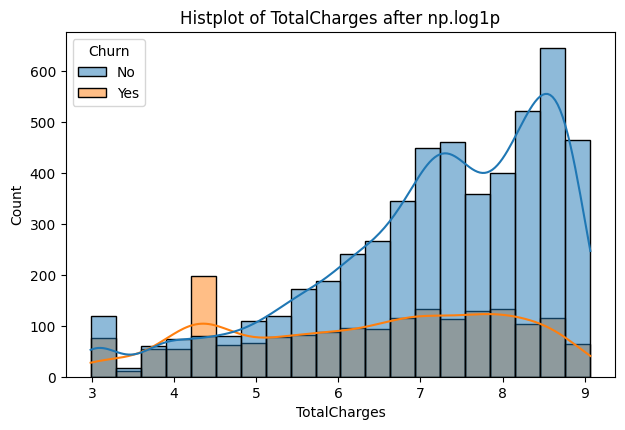

In [21]:
num_cols= [ 'TotalCharges']

fig, axes = plt.subplots(2,2, figsize=(12,8))
axes= axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(x=col, kde=True, bins=20, ax=axes[i], data=df_proc, hue="Churn")
    axes[i].set_title(f"Histplot of {col} after np.log1p")
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()    

In [22]:
df_proc.to_csv("../data/processed/Processed_customer_churn.csv")

In [23]:
from scipy.stats import skew

print(f"Skewness before log transformation: \n{df_proc[num_cols].skew()}")
print(f"\nSkewness after log transformation: \n{np.log1p(df_proc[num_cols]).skew()}")

Skewness before log transformation: 
TotalCharges   -0.744502
dtype: float64

Skewness after log transformation: 
TotalCharges   -1.158113
dtype: float64


In [24]:
df.loc[:, df.nunique() > 2].nunique()

customerID          7043
tenure                73
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
dtype: int64

In [25]:
bin_cols = ["gender", "Partner", "Contract",
            "Dependents", "PhoneService",
            "PaperlessBilling", "Churn"]

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges",  "SeniorCitizen"]

ohe_cols = ["MultipleLines", "PaymentMethod", "InternetService",
            "OnlineSecurity","OnlineBackup", "DeviceProtection", 
            "TechSupport", "StreamingTV", "StreamingMovies",]

In [26]:
le = LabelEncoder()

for col in bin_cols:
    df_proc[col] = le.fit_transform(df_proc[col])
    

In [27]:
X = df_proc.drop("Churn", axis=1)
y = df_proc["Churn"]

In [28]:
print("X shape:", X.shape)
print("y distribution:", y.value_counts().to_dict())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

X shape: (7043, 19)
y distribution: {0: 5174, 1: 1869}

Train: (5634, 19), Test: (1409, 19)


In [29]:
preprocessor = ColumnTransformer([
    ('ohe',   OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop="first"), ohe_cols),
    ('scale', StandardScaler(), numeric_cols),
], remainder='passthrough') 

| # | Model | Type |
|---|-------|------|
| 1 | Logistic Regression | Linear |
| 2 | Decision Tree | Tree |
| 3 | Random Forest | Ensemble (Bagging) |
| 4 | Gradient Boosting | Ensemble (Boosting) |
| 5 | AdaBoost | Ensemble (Boosting) |
| 6 | Extra Trees | Ensemble (Bagging) |
| 7 | Bagging | Ensemble (Bagging) |
| 8 | SVM | Kernel |
| 9 | KNN | Instance-based |
| 10 | Naive Bayes | Probabilistic |
| 11 | LDA | Discriminant |
| 12 | QDA | Discriminant |
| 13 | XGBoost | Gradient Boosting |
| 14 | LightGBM | Gradient Boosting |

In [30]:
models = {
    "Logistic Regression":   LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":         DecisionTreeClassifier(random_state=42),
    "Random Forest":         RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":     GradientBoostingClassifier(n_estimators=100, random_state=42),
    "AdaBoost":              AdaBoostClassifier(n_estimators=100, random_state=42),
    "Extra Trees":           ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Bagging":               BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "SVM":                   SVC(probability=True, random_state=42),
    "KNN":                   KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "Naive Bayes":           GaussianNB(),
    "XGBoost":               XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    "LightGBM":              LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),
}
print(f"{len(models)} models ready")

12 models ready


## Train & Evaluate All Models

In [31]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as IMBPipeline
from sklearn.metrics import balanced_accuracy_score, log_loss, matthews_corrcoef, recall_score

thresholds = np.linspace(0.1, 0.9, 50)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
trained = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    
    pipeline = IMBPipeline(steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    
    # Cross-validation (USE PIPELINE)
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    # Fit pipeline (NOT model)
    pipeline.fit(X_train, y_train)
    trained[name] = pipeline
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Probabilities
    # Predict probabilities
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Find best threshold
    best_threshold = 0.5
    best_f1 = 0

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        f1 = f1_score(y_test, y_pred_t)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    # Final prediction using best threshold
    y_pred = (y_prob >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    results.append({
        "Model": name,
        "threshold": t,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Bal.Accuracy": round(balanced_accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred), 4),
        "Log Loss": round(log_loss(y_test, y_prob), 4),
        "CV_AUC_mean": round(cv_scores.mean(), 4),
        "CV_AUC_std": round(cv_scores.std(), 4),
        "Specificity": round(tn/(tn+fp) if (tn+fp)>0 else 0, 4),
        "Sensitivity": round(tp/(tp+fn) if (tp+fn)>0 else 0, 4),
    })
    
    print(f"ROC-AUC={results[-1]['ROC-AUC']:.4f}")

results_df = pd.DataFrame(results).sort_values(
    "ROC-AUC", ascending=False
).reset_index(drop=True)

print("\nAll models trained!")

Training Logistic Regression... ROC-AUC=0.8469
Training Decision Tree... ROC-AUC=0.6656
Training Random Forest... ROC-AUC=0.8218
Training Gradient Boosting... ROC-AUC=0.8415
Training AdaBoost... ROC-AUC=0.8387
Training Extra Trees... ROC-AUC=0.7956
Training Bagging... ROC-AUC=0.8117
Training SVM... ROC-AUC=0.8264
Training KNN... ROC-AUC=0.7939
Training Naive Bayes... ROC-AUC=0.8117
Training XGBoost... ROC-AUC=0.8179
Training LightGBM... ROC-AUC=0.8347

All models trained!


In [32]:
results_df

,Model,threshold,Accuracy,Bal.Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Log Loss,CV_AUC_mean,CV_AUC_std,Specificity,Sensitivity
0,Logistic Regression,0.9,0.7793,0.7661,0.5644,0.7380,0.6396,0.8469,0.4936,0.4854,0.8490,0.0125,0.7942,0.7380
1,Gradient Boosting,0.9,0.7651,0.7633,0.5410,0.7594,0.6318,0.8415,0.4808,0.4394,0.8453,0.0122,0.7671,0.7594
2,AdaBoost,0.9,0.7736,0.7537,0.5577,0.7112,0.6251,0.8387,0.4734,0.6008,0.8441,0.0112,0.7961,0.7112
3,LightGBM,0.9,0.7388,0.7693,0.5049,0.8342,0.6290,0.8347,0.4793,0.4449,0.8316,0.0086,0.7043,0.8342
4,SVM,0.9,0.7537,0.7632,0.5242,0.7834,0.6281,0.8264,0.4751,0.4931,0.8266,0.0122,0.7430,0.7834
5,Random Forest,0.9,0.7168,0.7526,0.4806,0.8289,0.6084,0.8218,0.4478,0.5543,0.8203,0.0126,0.6763,0.8289
6,XGBoost,0.9,0.7317,0.7465,0.4966,0.7781,0.6062,0.8179,0.4417,0.4913,0.8211,0.0079,0.7150,0.7781
7,Naive Bayes,0.9,0.6856,0.7279,0.4493,0.8182,0.5801,0.8117,0.4028,2.6788,0.8232,0.0133,0.6377,0.8182
8,Bagging,0.9,0.7026,0.7421,0.4661,0.8262,0.5959,0.8117,0.4283,0.7627,0.8128,0.0088,0.6580,0.8262
9,Extra Trees,0.9,0.6941,0.7295,0.4568,0.8048,0.5828,0.7956,0.4061,0.7158,0.7966,0.0123,0.6541,0.8048


In [33]:
# Full results table sorted by ROC-AUC
print("=" * 100)
print("MODEL COMPARISON — Sorted by ROC-AUC")
print("=" * 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(results_df.to_string(index=False))

MODEL COMPARISON — Sorted by ROC-AUC
              Model  threshold  Accuracy  Bal.Accuracy  Precision  Recall     F1  ROC-AUC    MCC  Log Loss  CV_AUC_mean  CV_AUC_std  Specificity  Sensitivity
Logistic Regression        0.9    0.7793        0.7661     0.5644  0.7380 0.6396   0.8469 0.4936    0.4854       0.8490      0.0125       0.7942       0.7380
  Gradient Boosting        0.9    0.7651        0.7633     0.5410  0.7594 0.6318   0.8415 0.4808    0.4394       0.8453      0.0122       0.7671       0.7594
           AdaBoost        0.9    0.7736        0.7537     0.5577  0.7112 0.6251   0.8387 0.4734    0.6008       0.8441      0.0112       0.7961       0.7112
           LightGBM        0.9    0.7388        0.7693     0.5049  0.8342 0.6290   0.8347 0.4793    0.4449       0.8316      0.0086       0.7043       0.8342
                SVM        0.9    0.7537        0.7632     0.5242  0.7834 0.6281   0.8264 0.4751    0.4931       0.8266      0.0122       0.7430       0.7834
      Random Fo

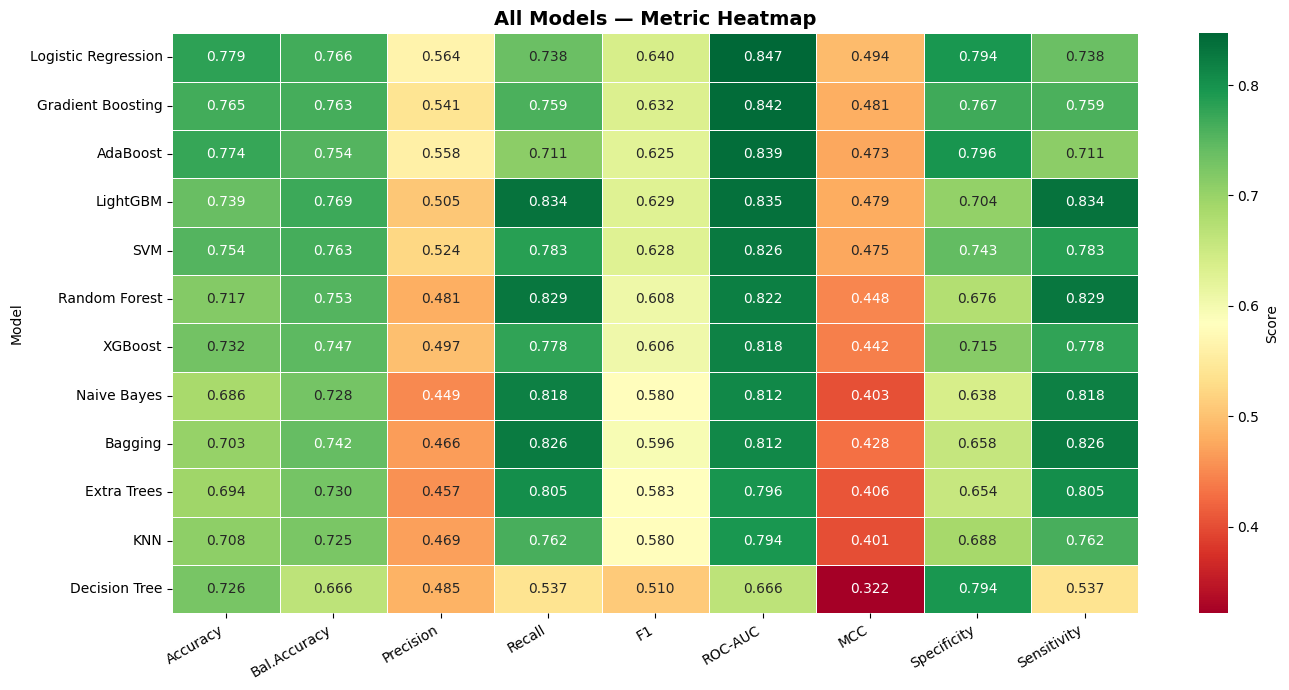

In [34]:
# Heatmap of all metrics
fig, ax = plt.subplots(figsize=(14, 7))
plot_df = results_df.set_index('Model')[
    ['Accuracy','Bal.Accuracy','Precision','Recall','F1','ROC-AUC','MCC','Specificity','Sensitivity']
]
sns.heatmap(plot_df, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('All Models — Metric Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
fig.savefig("../reports/images/with_log/metrics_heatmap.png")
plt.show()


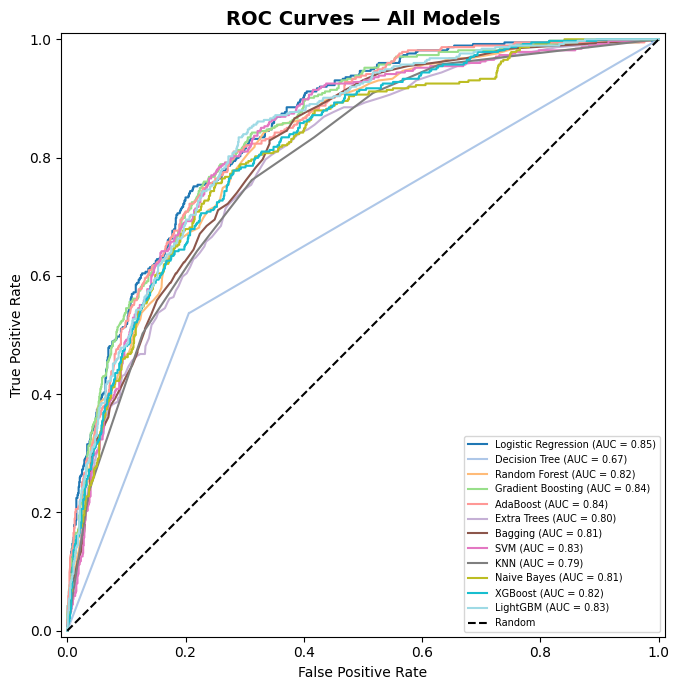

In [35]:
from sklearn.metrics import RocCurveDisplay


fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(trained)))

for (name, model), color in zip(trained.items(), colors):
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    
    display = RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=name,
        ax=ax
    )
    
    # set color AFTER plotting
    display.line_.set_color(color)
    display.line_.set_alpha(1)

ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=7)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

plt.tight_layout()
fig.savefig("../reports/images/with_log/roc_curves.png")
plt.show()

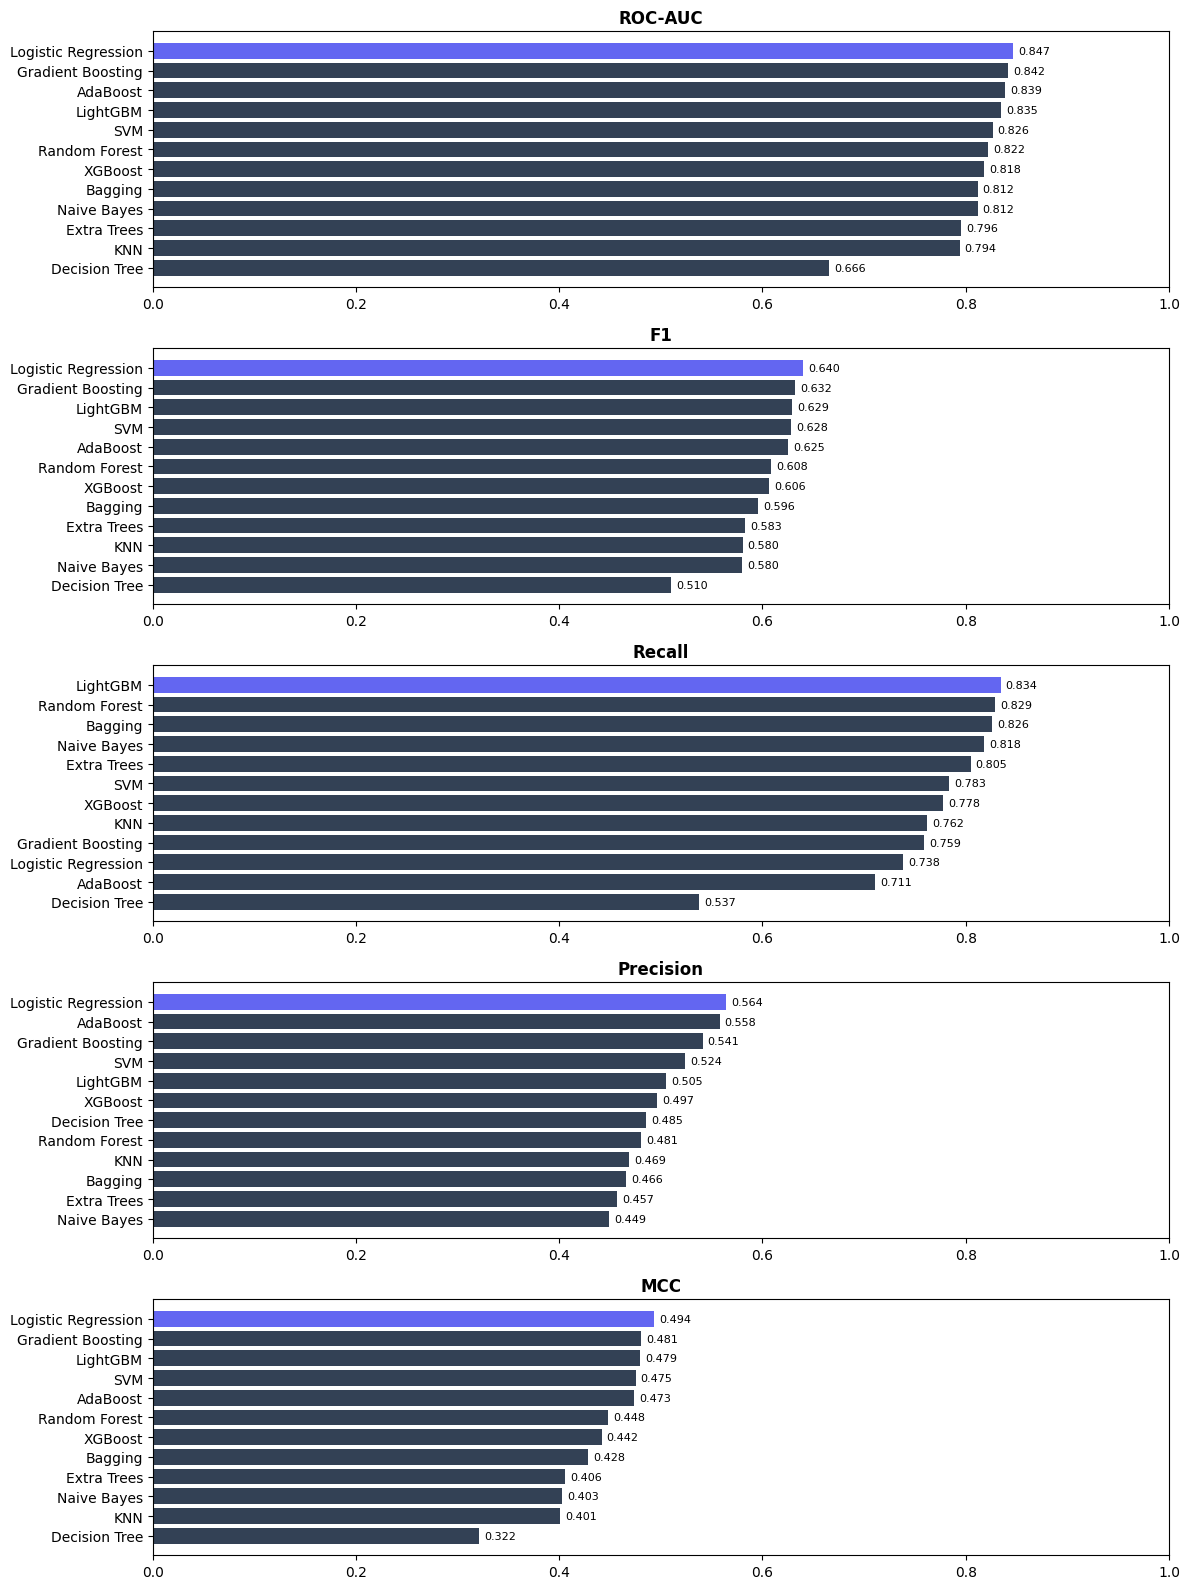

In [36]:
metrics_to_plot = ['ROC-AUC', 'F1', 'Recall', 'Precision', 'MCC']
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(12, 16))

for ax, metric in zip(axes, metrics_to_plot):
    sorted_df = results_df.sort_values(metric, ascending=True)
    colors_bar = ['#6366f1' if v == sorted_df[metric].max() else '#334155' for v in sorted_df[metric]]
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors_bar, edgecolor='none')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
fig.savefig("../reports/images/with_log/metrics.png")
plt.show()


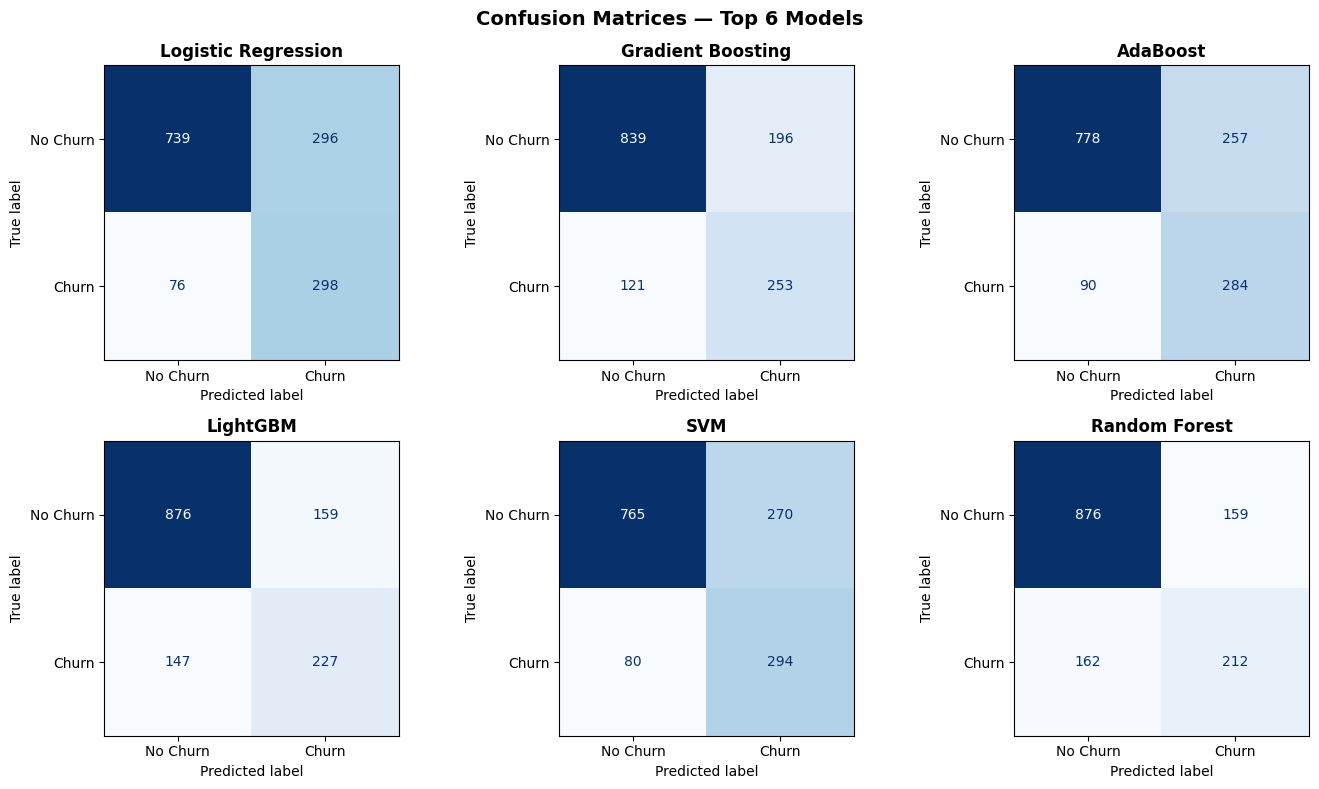

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay


top6 = results_df.head(6)['Model'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, name in zip(axes.ravel(), top6):
    model = trained[name]
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, colorbar=False,
        display_labels=['No Churn','Churn'],
        cmap='Blues'
    )
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — Top 6 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig("../reports/images/with_log/Confusion_matrix_without_log.png")
plt.show()


In [38]:
best_name  = results_df.iloc[0]['Model']
best_model = trained[best_name]

print(f"🏆 Best Model: {best_name}")
print(f"   ROC-AUC: {results_df.iloc[0]['ROC-AUC']}")
print(f"   F1 Score: {results_df.iloc[0]['F1']}")
print()

y_pred_best = best_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))


🏆 Best Model: Logistic Regression
   ROC-AUC: 0.8469
   F1 Score: 0.6396

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



🏆 Best Model: Gradient Boosting
   ROC-AUC: 0.8411
   F1 Score: 0.631

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.81      0.84      1035
       Churn       0.56      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.77      0.78      1409

In [39]:
import pickle

artifacts = {
    'model': best_model,
    'preprocessor': preprocessor,
    'model_name': best_name,
    'feature_names': list(X.columns)
}

with open('../reports/models/best_model_with_log.pkl', 'wb') as f:
    pickle.dump(models, f)

print(f"Saved best_model.pkl ({best_name})")
print("   Load with: pickle.load(open('best_model.pkl', 'rb'))")


Saved best_model.pkl (Logistic Regression)
   Load with: pickle.load(open('best_model.pkl', 'rb'))


In [40]:
import os
import pickle

save_dir = "../reports/models/"
os.makedirs(save_dir, exist_ok=True)

for name, model in trained.items():
    file_name = name.replace(" ", "_").lower() + ".pkl"
    file_path = os.path.join(save_dir, file_name)
    
    with open(file_path, "wb") as f:
        pickle.dump(model, f)
    
    print(f" Saved:  {file_name}")

 Saved:  logistic_regression.pkl
 Saved:  decision_tree.pkl
 Saved:  random_forest.pkl
 Saved:  gradient_boosting.pkl
 Saved:  adaboost.pkl
 Saved:  extra_trees.pkl
 Saved:  bagging.pkl
 Saved:  svm.pkl
 Saved:  knn.pkl
 Saved:  naive_bayes.pkl
 Saved:  xgboost.pkl
 Saved:  lightgbm.pkl


In [41]:
df_proc.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   str    
 17  Monthl